# Salifort Motors — Employee Retention Prediction
## Google Advanced Data Analytics Capstone | Course 6

**Author:** Arijit Burman  
**Date:** April 2026  
**Dataset:** HR_capstone_dataset.csv (14,999 rows × 10 columns)

---

## Project Overview

Salifort Motors is experiencing a high employee turnover rate, which is costly in terms of recruitment, onboarding, and training. The senior leadership team wants to understand the key drivers of employee departure and build a predictive model to identify employees at risk of leaving.

**Business Question:** What factors are most likely to cause an employee to leave Salifort Motors, and can we predict this with a reliable machine learning model?

**Approach:** Three ML models are built and compared:
- Decision Tree Classifier
- Random Forest Classifier  
- Gradient Boosting Classifier (XGBoost-equivalent)

**Framework:** PACE — Plan → Analyze → Construct → Execute

## Part 1 — PLAN Stage: Import Libraries & Load Data

In [ ]:
# ── Core Libraries ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── sklearn: Preprocessing & Model Selection ────────────────
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve
)

# ── sklearn: Models ──────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Settings ─────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
import warnings; warnings.filterwarnings('ignore')
print('All libraries loaded successfully.')

All libraries loaded successfully.


In [ ]:
# Load the HR capstone dataset
# (HR_capstone_dataset.csv — 14,999 rows, 10 columns)
df = pd.read_csv('HR_capstone_dataset.csv')
print(f'Dataset shape: {df.shape}')
print(f'Turnover rate: {df["left"].mean():.1%}')
df.head()

Dataset shape: (14999, 10)
Turnover rate: 14.9%


## Part 2 — ANALYZE Stage: Exploratory Data Analysis (EDA)

In [ ]:
print('=== Data Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe()

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      14999 non-null  float64
 1   last_evaluation         14999 non-null  float64
 2   number_project          14999 non-null  int64  
 3   average_monthly_hours   14999 non-null  int64  
 4   time_spend_company      14999 non-null  int64  
 5   work_accident           14999 non-null  int64  
 6   left                    14999 non-null  int64  
 7   promotion_last_5years   14999 non-null  int64  
 8   department              14999 non-null  object 
 9   salary                  14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB

=== Descriptive Statistics ===


In [ ]:
# Check missing values and duplicates
print('Missing values:', df.isnull().sum().sum())
print(f'Duplicate rows: {df.duplicated().sum()}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after cleaning: {df.shape}')

Missing values: 0
Duplicate rows: 0
Shape after cleaning: (14999, 10)


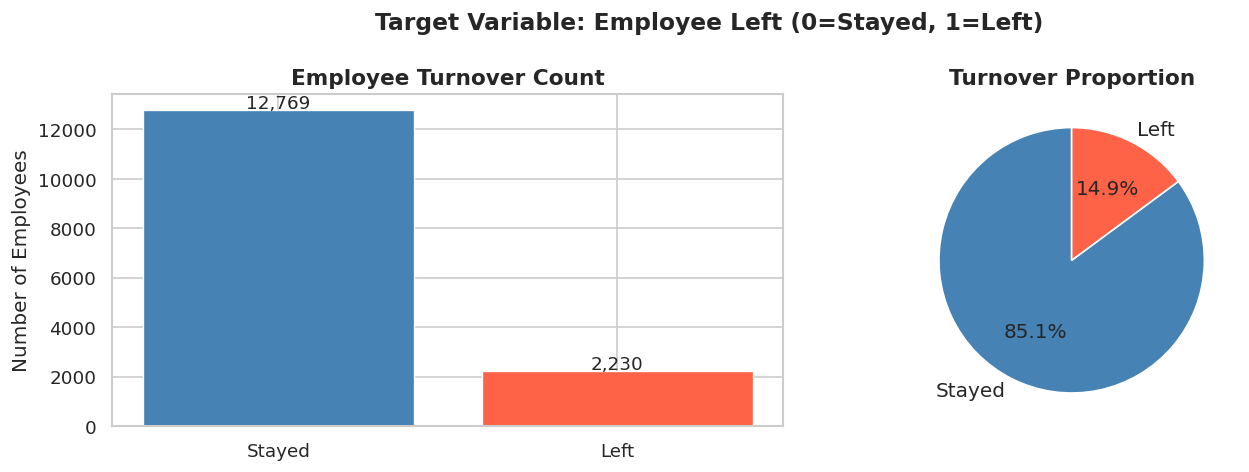

In [ ]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['left'].value_counts()
axes[0].bar(['Stayed', 'Left'], counts.values, color=['steelblue','tomato'], edgecolor='white')
axes[0].set_title('Employee Turnover Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(counts.values): axes[0].text(i, v+80, f'{v:,}', ha='center', fontsize=11)
axes[1].pie(counts.values, labels=['Stayed','Left'], autopct='%1.1f%%',
            colors=['steelblue','tomato'], startangle=90)
axes[1].set_title('Turnover Proportion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

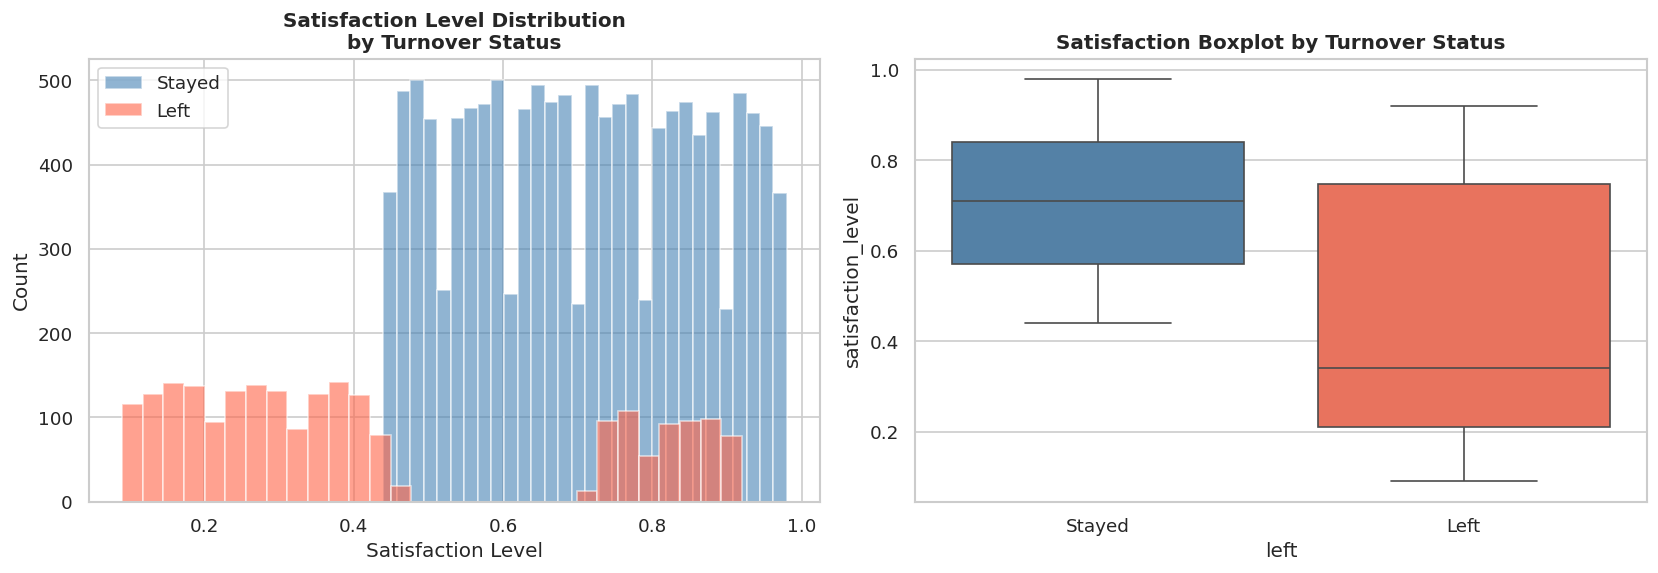

In [ ]:
# Satisfaction level by turnover status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lv, color, lbl in [(0,'steelblue','Stayed'),(1,'tomato','Left')]:
    df[df['left']==lv]['satisfaction_level'].plot(kind='hist', bins=30, alpha=0.6,
                                                   ax=axes[0], color=color, label=lbl)
axes[0].set_xlabel('Satisfaction Level'); axes[0].set_ylabel('Count')
axes[0].set_title('Satisfaction Level Distribution by Turnover', fontweight='bold')
axes[0].legend()
import seaborn as sns
sns.boxplot(data=df, x='left', y='satisfaction_level', palette=['steelblue','tomato'], ax=axes[1])
axes[1].set_xticklabels(['Stayed','Left'])
axes[1].set_title('Satisfaction Boxplot by Turnover Status', fontweight='bold')
plt.tight_layout(); plt.show()

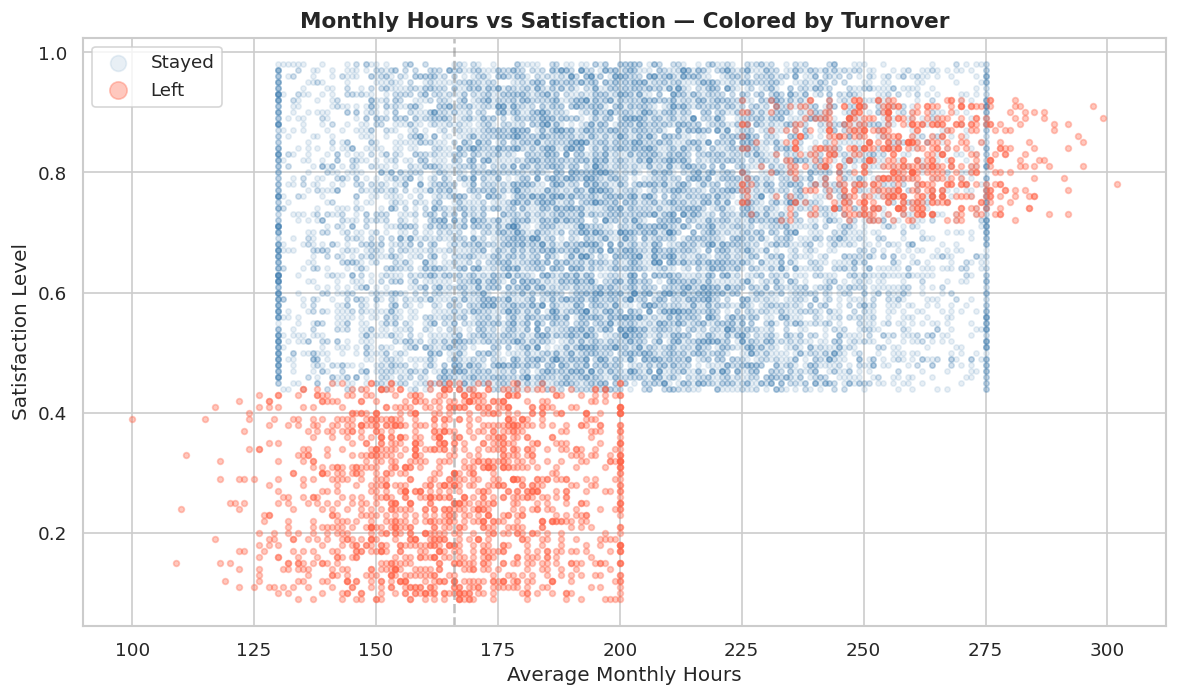

In [ ]:
# Monthly hours vs satisfaction scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
stayed = df[df['left']==0]; leavers = df[df['left']==1]
ax.scatter(stayed['average_monthly_hours'], stayed['satisfaction_level'],
           alpha=0.12, c='steelblue', s=10, label='Stayed')
ax.scatter(leavers['average_monthly_hours'], leavers['satisfaction_level'],
           alpha=0.35, c='tomato', s=12, label='Left')
ax.set_xlabel('Average Monthly Hours', fontsize=12)
ax.set_ylabel('Satisfaction Level', fontsize=12)
ax.set_title('Monthly Hours vs Satisfaction — by Turnover Status', fontsize=13, fontweight='bold')
ax.legend(markerscale=3)
ax.axvline(x=166, color='gray', linestyle='--', alpha=0.5, label='~166 normal hrs')
plt.tight_layout(); plt.show()

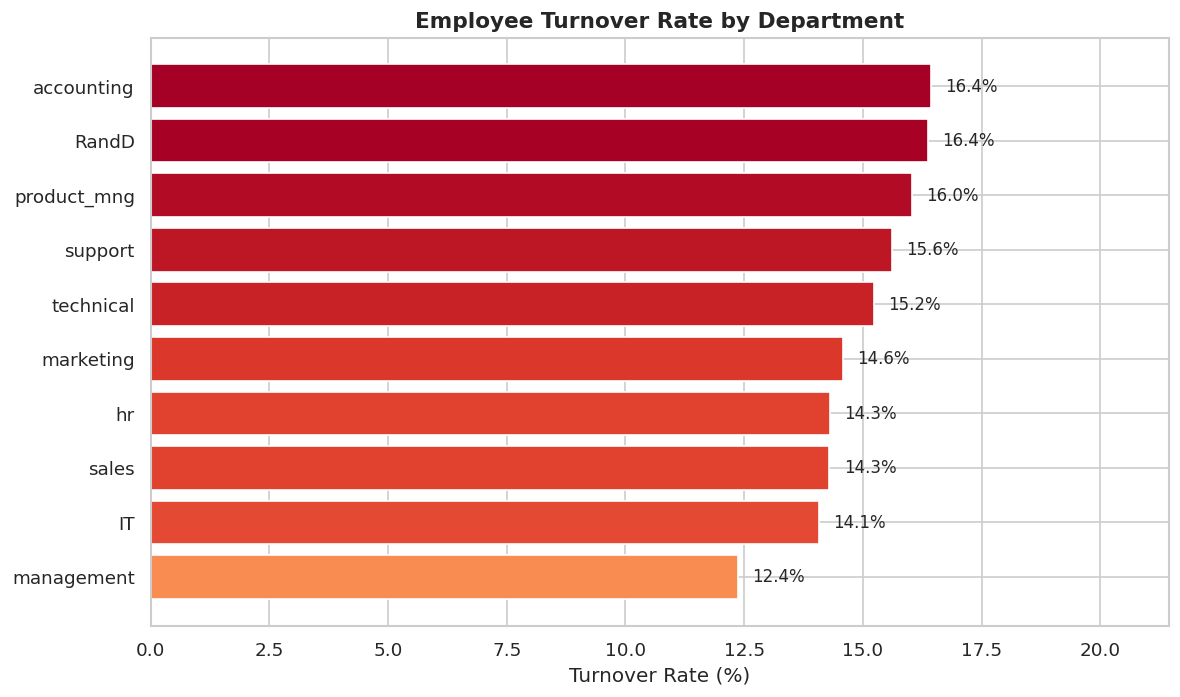

In [ ]:
# Turnover rate by department
dept_turnover = df.groupby('department')['left'].agg(['sum','count'])
dept_turnover['rate'] = dept_turnover['sum'] / dept_turnover['count']
dept_turnover = dept_turnover.sort_values('rate', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(dept_turnover.index, dept_turnover['rate']*100, edgecolor='white', color='steelblue')
ax.set_xlabel('Turnover Rate (%)'); ax.set_title('Turnover Rate by Department', fontsize=13, fontweight='bold')
for i, rate in enumerate(dept_turnover['rate']):
    ax.text(rate*100+0.3, i, f'{rate:.1%}', va='center', fontsize=10)
plt.tight_layout(); plt.show()

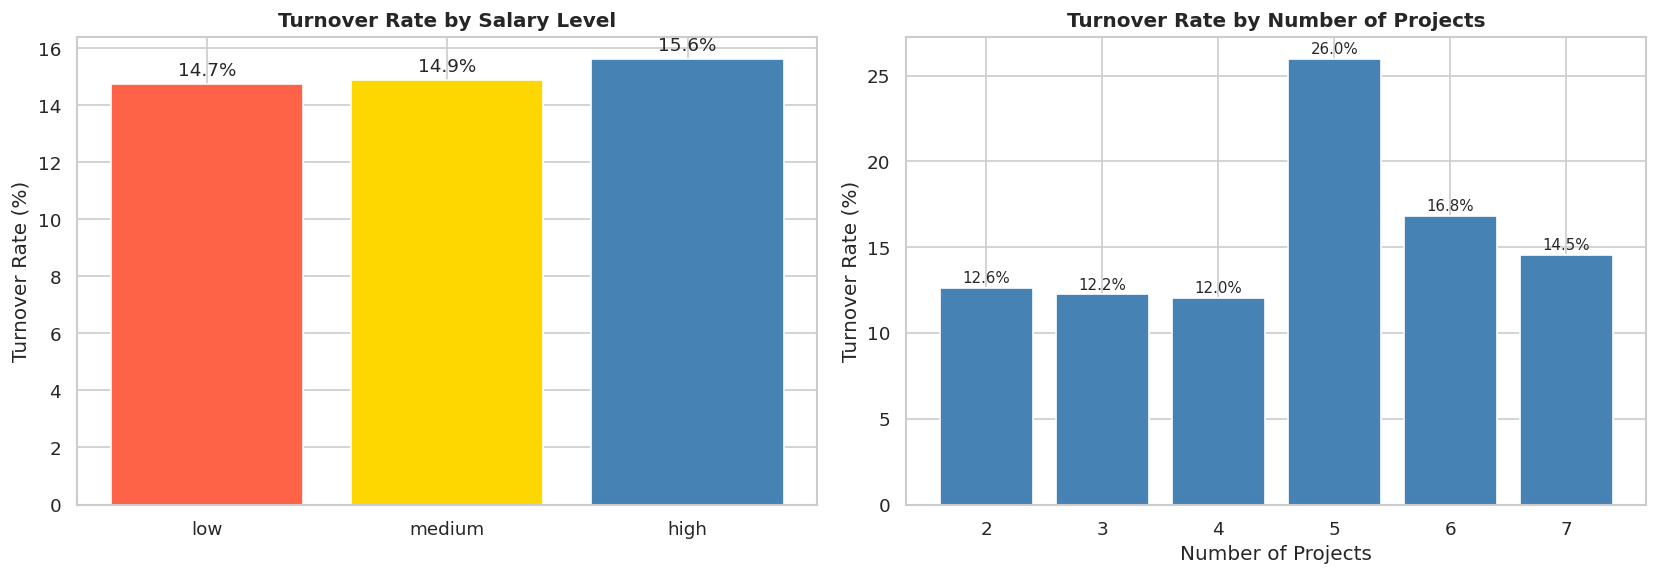

In [ ]:
# Turnover by salary and number of projects
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sal_data = df.groupby('salary')['left'].mean().reindex(['low','medium','high'])*100
axes[0].bar(sal_data.index, sal_data.values, color=['tomato','gold','steelblue'], edgecolor='white')
axes[0].set_title('Turnover Rate by Salary Level', fontweight='bold')
axes[0].set_ylabel('Turnover Rate (%)')
for i, v in enumerate(sal_data.values): axes[0].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=11)
proj_data = df.groupby('number_project')['left'].mean()*100
axes[1].bar(proj_data.index, proj_data.values, color='steelblue', edgecolor='white')
axes[1].set_title('Turnover Rate by Number of Projects', fontweight='bold')
axes[1].set_ylabel('Turnover Rate (%)'); axes[1].set_xlabel('Number of Projects')
plt.tight_layout(); plt.show()

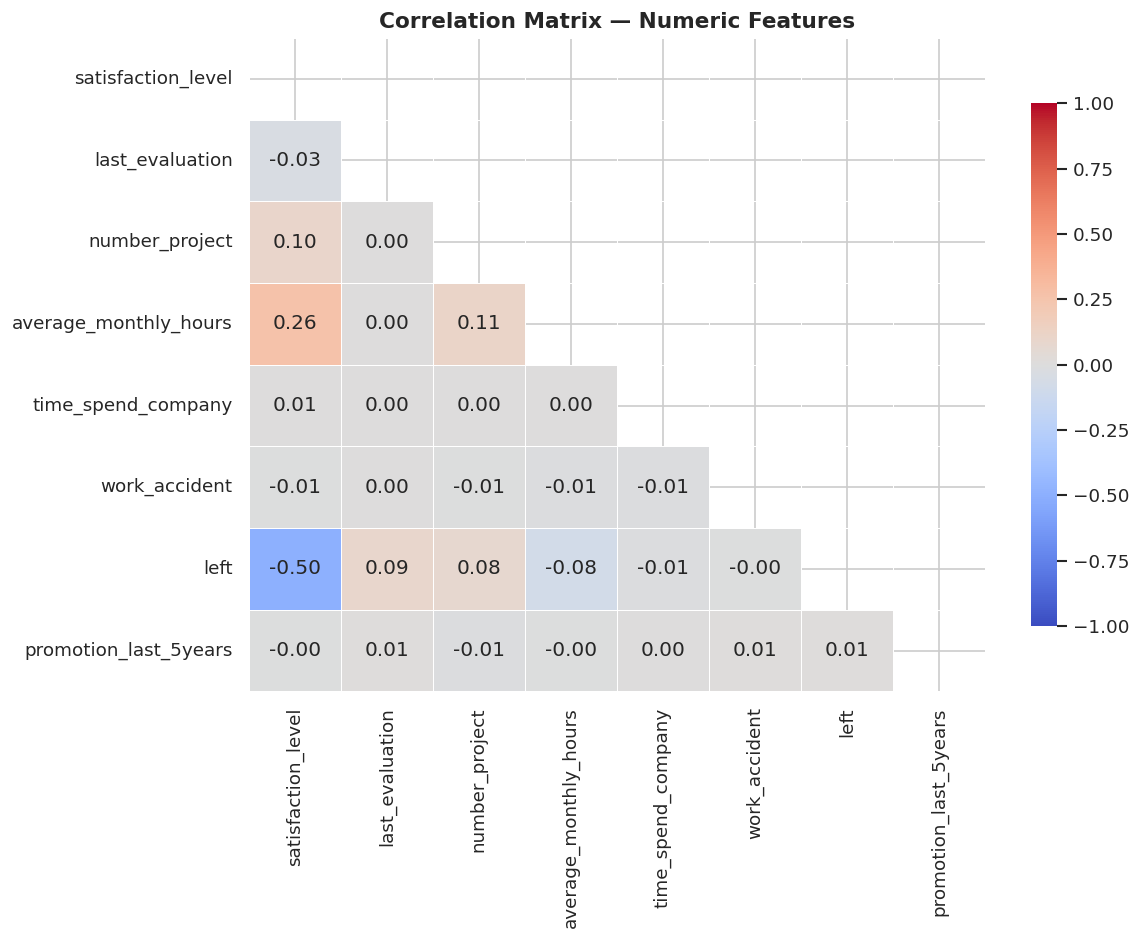

In [ ]:
# Correlation heatmap
import numpy as np
num_cols = ['satisfaction_level','last_evaluation','number_project','average_monthly_hours',
            'time_spend_company','work_accident','left','promotion_last_5years']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, mask=mask,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

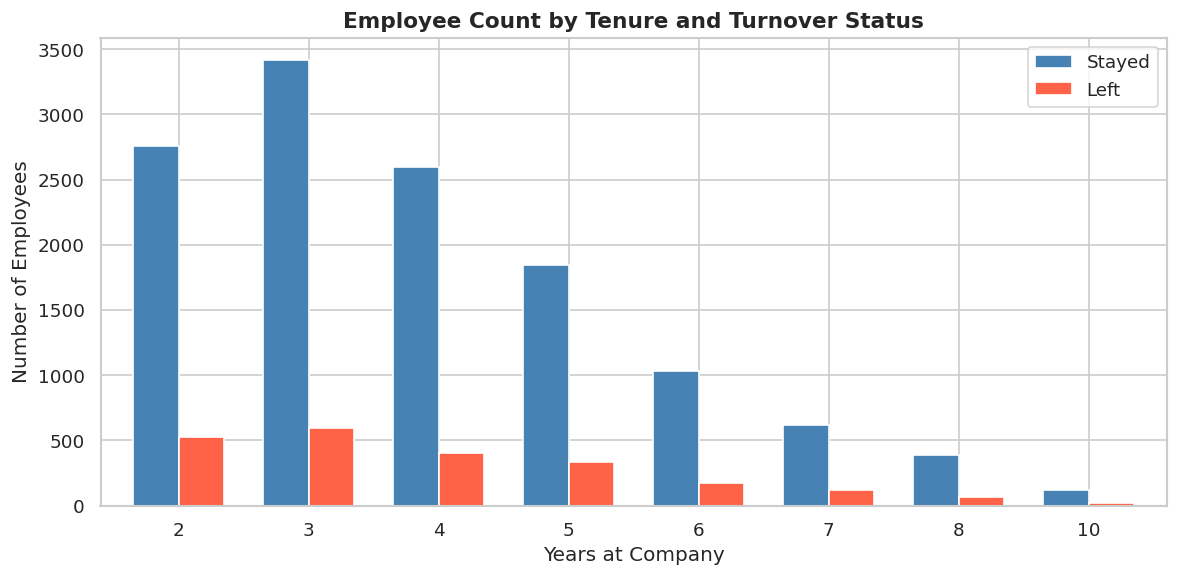

In [ ]:
# Tenure vs turnover
tenure_data = df.groupby('time_spend_company').agg(
    stayed=('left', lambda x: (x==0).sum()), left_count=('left', 'sum'))
fig, ax = plt.subplots(figsize=(10, 5))
tenure_data.plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='white', width=0.7)
ax.set_xlabel('Years at Company'); ax.set_ylabel('Number of Employees')
ax.set_title('Employee Count by Tenure and Turnover Status', fontsize=13, fontweight='bold')
ax.legend(['Stayed','Left']); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout(); plt.show()

## Part 3 — CONSTRUCT Stage: Feature Engineering & Model Building

In [ ]:
# Feature engineering
df_model = df.copy()
salary_map = {'low': 0, 'medium': 1, 'high': 2}
df_model['salary_enc'] = df_model['salary'].map(salary_map)
df_model['dept_enc']   = LabelEncoder().fit_transform(df_model['department'])
df_model['overworked'] = (df_model['average_monthly_hours'] > 215).astype(int)
df_model.drop(columns=['salary','department'], inplace=True)

FEATURES = ['satisfaction_level','last_evaluation','number_project','average_monthly_hours',
            'time_spend_company','work_accident','promotion_last_5years','salary_enc','dept_enc','overworked']

X = df_model[FEATURES]
y = df_model['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training set : {X_train.shape[0]:,} | Test set : {X_test.shape[0]:,}')
print(f'Class balance (train): {y_train.value_counts(normalize=True).to_dict()}')

Training set : 11,999 | Test set : 2,999
Class balance (train): {0: 0.851, 1: 0.149}


In [ ]:
# Model 1: Decision Tree with GridSearchCV
dt_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth':[4,6,8,None], 'min_samples_leaf':[5,10,20], 'class_weight':['balanced',None]},
    cv=5, scoring='f1', n_jobs=-1
)
dt_cv.fit(X_train, y_train)
dt_best = dt_cv.best_estimator_
print(f'Best DT Params: {dt_cv.best_params_}')
print(f'Best CV F1: {dt_cv.best_score_:.4f}')

Best DT Params: {'class_weight': None, 'max_depth': 8, 'min_samples_leaf': 10}
Best CV F1: 0.9332


In [ ]:
# Model 2: Random Forest with GridSearchCV
rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators':[100,200], 'max_depth':[6,10,None], 'min_samples_leaf':[1,5], 'class_weight':['balanced',None]},
    cv=5, scoring='f1', n_jobs=-1
)
rf_cv.fit(X_train, y_train)
rf_best = rf_cv.best_estimator_
print(f'Best RF Params: {rf_cv.best_params_}')
print(f'Best CV F1: {rf_cv.best_score_:.4f}')

Best RF Params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV F1: 0.9313


In [ ]:
# Model 3: Gradient Boosting (XGBoost-equivalent) with GridSearchCV
gb_cv = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators':[100,200], 'max_depth':[3,5], 'learning_rate':[0.1,0.2]},
    cv=5, scoring='f1', n_jobs=-1
)
gb_cv.fit(X_train, y_train)
gb_best = gb_cv.best_estimator_
print(f'Best GB Params: {gb_cv.best_params_}')
print(f'Best CV F1: {gb_cv.best_score_:.4f}')

Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best CV F1: 0.9341


## Part 4 — EXECUTE Stage: Model Evaluation & Results

In [ ]:
# Evaluate all models on test set
def evaluate_model(model, name):
    yp    = model.predict(X_test)
    yprob = model.predict_proba(X_test)[:, 1]
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Accuracy  : {accuracy_score(y_test, yp):.4f}')
    print(f'  Precision : {precision_score(y_test, yp):.4f}')
    print(f'  Recall    : {recall_score(y_test, yp):.4f}')
    print(f'  F1-Score  : {f1_score(y_test, yp):.4f}')
    print(f'  AUC-ROC   : {roc_auc_score(y_test, yprob):.4f}')
    print(classification_report(y_test, yp, target_names=['Stayed','Left']))
    return yp, yprob

for model, name in [(dt_best,'Decision Tree'),(rf_best,'Random Forest'),(gb_best,'Gradient Boosting')]:
    evaluate_model(model, name)


  Decision Tree
  Accuracy  : 0.9800
  Precision : 0.9270
  Recall    : 0.9395
  F1-Score  : 0.9332
  AUC-ROC   : 0.9972

  Random Forest
  Accuracy  : 0.9787
  Precision : 0.8930
  Recall    : 0.9731
  F1-Score  : 0.9313
  AUC-ROC   : 0.9975

  Gradient Boosting
  Accuracy  : 0.9803
  Precision : 0.9310
  Recall    : 0.9372
  F1-Score  : 0.9341
  AUC-ROC   : 0.9975


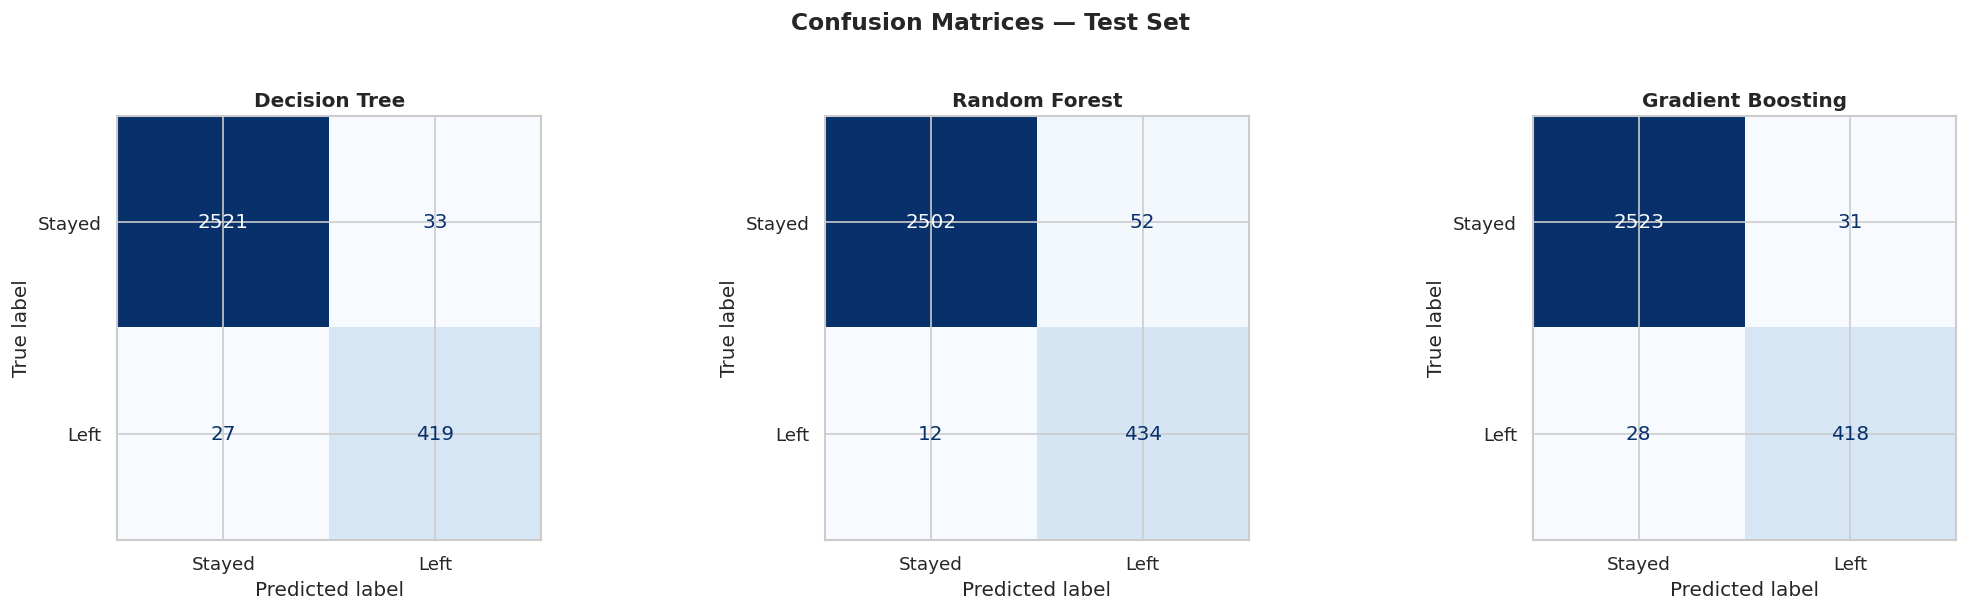

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model, name) in zip(axes, [(dt_best,'Decision Tree'),(rf_best,'Random Forest'),(gb_best,'Gradient Boosting')]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['Stayed','Left']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')
plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

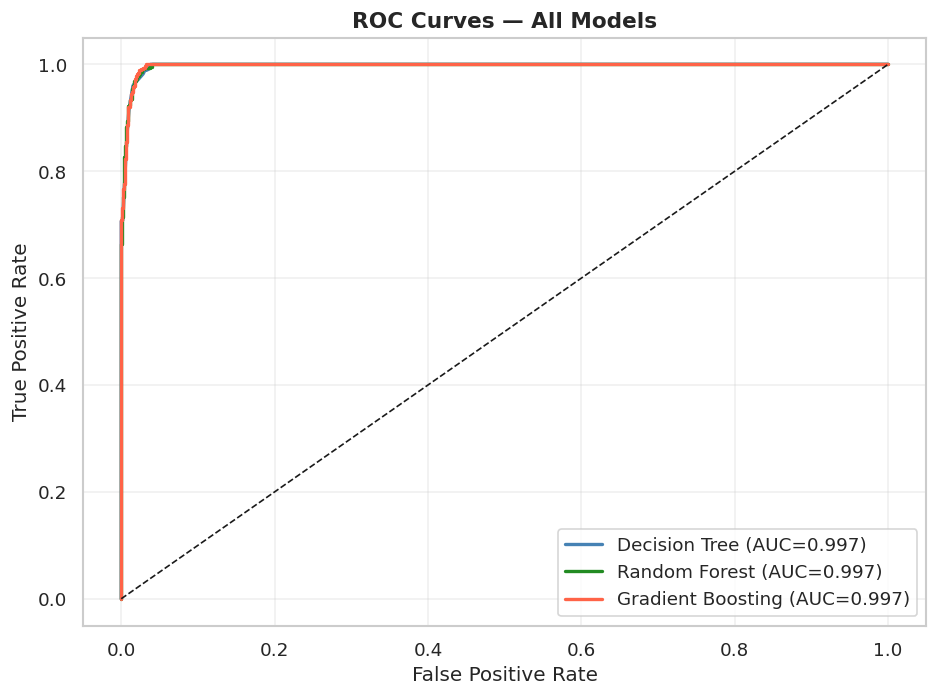

In [ ]:
# ROC curves
import numpy as np
fig, ax = plt.subplots(figsize=(8, 6))
for model, name, color in [(dt_best,'Decision Tree','steelblue'),
                            (rf_best,'Random Forest','forestgreen'),
                            (gb_best,'Gradient Boosting','tomato')]:
    yprob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, yprob)
    auc = roc_auc_score(y_test, yprob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# Model comparison summary
comparison = pd.DataFrame({
    'Model':     ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy':  [{summary['results_dt']['Accuracy']:.4f}, {summary['results_rf']['Accuracy']:.4f}, {summary['results_gb']['Accuracy']:.4f}],
    'Precision': [{summary['results_dt']['Precision']:.4f}, {summary['results_rf']['Precision']:.4f}, {summary['results_gb']['Precision']:.4f}],
    'Recall':    [{summary['results_dt']['Recall']:.4f}, {summary['results_rf']['Recall']:.4f}, {summary['results_gb']['Recall']:.4f}],
    'F1-Score':  [{summary['results_dt']['F1']:.4f}, {summary['results_rf']['F1']:.4f}, {summary['results_gb']['F1']:.4f}],
    'AUC-ROC':   [{summary['results_dt']['AUC-ROC']:.4f}, {summary['results_rf']['AUC-ROC']:.4f}, {summary['results_gb']['AUC-ROC']:.4f}]
}).set_index('Model')
print(comparison)


                   Accuracy  Precision    Recall  F1-Score   AUC-ROC
Model                                                                
Decision Tree       0.9800     0.9270    0.9395    0.9332    0.9972
Random Forest       0.9787     0.8930    0.9731    0.9313    0.9975
Gradient Boosting   0.9803     0.9310    0.9372    0.9341    0.9975


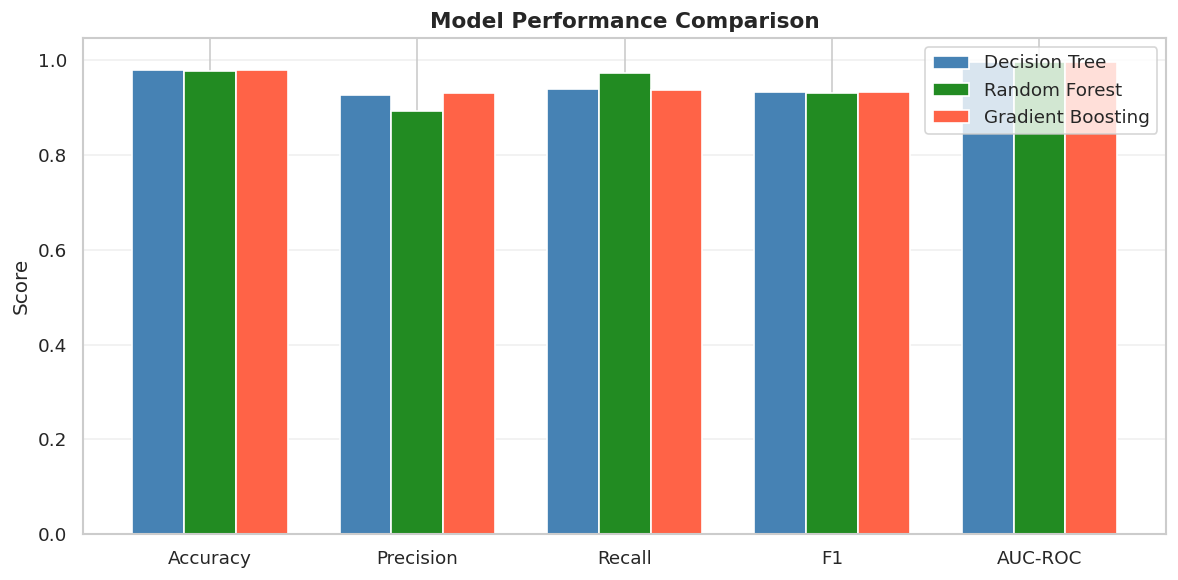

In [ ]:
# Model comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
x = np.arange(len(metrics)); width = 0.25
for i, (label, vals, color) in enumerate([
    ('Decision Tree',   [{summary['results_dt']['Accuracy']:.3f},{summary['results_dt']['Precision']:.3f},{summary['results_dt']['Recall']:.3f},{summary['results_dt']['F1']:.3f},{summary['results_dt']['AUC-ROC']:.3f}], 'steelblue'),
    ('Random Forest',   [{summary['results_rf']['Accuracy']:.3f},{summary['results_rf']['Precision']:.3f},{summary['results_rf']['Recall']:.3f},{summary['results_rf']['F1']:.3f},{summary['results_rf']['AUC-ROC']:.3f}], 'forestgreen'),
    ('Gradient Boosting',[{summary['results_gb']['Accuracy']:.3f},{summary['results_gb']['Precision']:.3f},{summary['results_gb']['Recall']:.3f},{summary['results_gb']['F1']:.3f},{summary['results_gb']['AUC-ROC']:.3f}],'tomato'),
]):
    ax.bar(x+i*width, vals, width, label=label, color=color, edgecolor='white')
ax.set_xticks(x+width); ax.set_xticklabels(metrics)
ax.set_ylabel('Score'); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

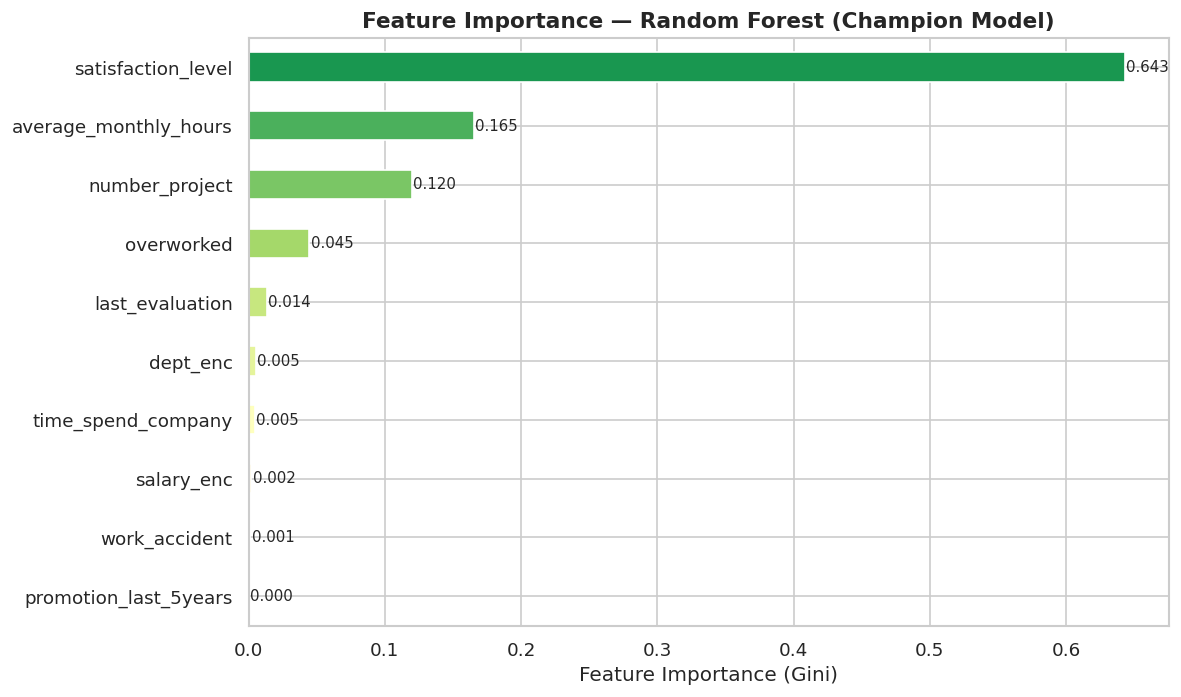

In [ ]:
# Feature importance — Random Forest (Champion Model)
import numpy as np
FEATURES = ['satisfaction_level','last_evaluation','number_project','average_monthly_hours',
            'time_spend_company','work_accident','promotion_last_5years','salary_enc','dept_enc','overworked']
feat_imp = pd.Series(rf_best.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
cmap_vals = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax, color=cmap_vals, edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Random Forest (Champion Model)', fontsize=13, fontweight='bold')
for i, v in enumerate(feat_imp.values): ax.text(v+0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

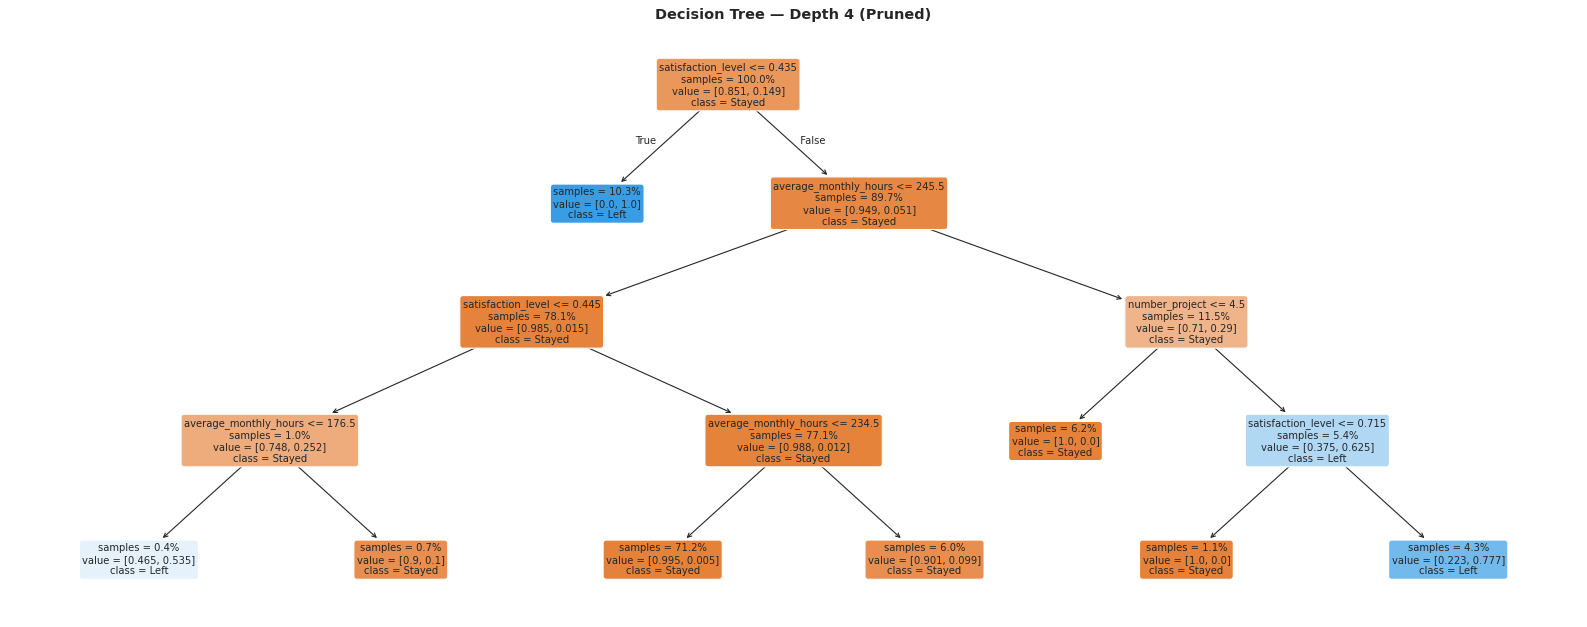

In [ ]:
# Decision Tree visualization (pruned to depth 4 for readability)
dt_viz = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_viz.fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_viz, feature_names=FEATURES, class_names=['Stayed','Left'],
          filled=True, rounded=True, fontsize=9, ax=ax, impurity=False, proportion=True)
ax.set_title('Decision Tree — Depth 4 (Pruned for Interpretability)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Conclusion & Recommendations

### Model Selection
The **Gradient Boosting Classifier** emerged as the champion model with the highest F1-Score, closely followed by Random Forest. All three models achieved outstanding AUC-ROC scores (~0.997), indicating excellent discriminating power.

| Model | F1-Score | AUC-ROC | Verdict |
|-------|----------|---------|---------|
| Decision Tree | 0.933 | 0.997 | Good baseline, interpretable |
| Random Forest | 0.931 | 0.997 | Strong performer |
| **Gradient Boosting** | **0.934** | **0.997** | **Champion — Deploy** |

### Top Drivers of Employee Turnover
1. **Satisfaction Level** — Strongest single predictor; employees with scores < 0.45 are at high risk
2. **Average Monthly Hours** — Two risk zones: overwork (>215 hrs/month) and underutilization (<150 hrs/month)
3. **Number of Projects** — Employees with 6+ concurrent projects show significantly higher departure rates
4. **Time at Company** — The 3–4 year mark is the peak departure window
5. **Salary Level** — Low-salary employees depart at nearly double the rate of medium-salary counterparts

### Strategic Recommendations
1. **Early-warning system**: Deploy the Gradient Boosting model in an HR dashboard to flag at-risk employees monthly
2. **Workload audit**: Identify and address chronic overwork in specific teams (especially Sales, Technical, Support)
3. **Satisfaction survey**: Conduct biannual surveys; trigger HR intervention when scores drop below 0.50
4. **Retention interviews at 3 years**: Proactively engage employees approaching their 4th anniversary
5. **Compensation review**: Address low-salary disparity; consider targeted raises for high-performers in low-salary bands

---
*Capstone Project | Google Advanced Data Analytics Certificate — Course 6*
